In [1]:
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
TICKERS = ["RYAAY", "LHA.DE", "AF.PA", "IAG.L"]
OUTPUT_DIR = "output"

# "annual" gives ~5 fiscal years; "quarterly" gives ~4-7 quarters but is patchier.
FREQ = "annual"

# Flow items (revenue, COGS) are per-period, so the day count has to match the
# period or DSO/DPO/DIO come out ~4x too high on quarterly data.
DAYS_IN_PERIOD = {"annual": 365, "quarterly": 91}

In [3]:
BALANCE_ITEMS = {
    "receivables": ["Accounts Receivable", "Receivables", "Net Receivables"],
    "payables": ["Accounts Payable", "Payables", "Payables And Accrued Expenses"],
    "inventory": ["Inventory", "Inventories"],
    "current_assets": ["Current Assets", "Total Current Assets"],
    "current_liabilities": ["Current Liabilities", "Total Current Liabilities"],
    "cash": ["Cash And Cash Equivalents", "Cash Cash Equivalents And Short Term Investments"],
}
INCOME_ITEMS = {
    "revenue": ["Total Revenue", "Revenue"],
    "cogs": ["Cost Of Revenue", "Reconciled Cost Of Revenue", "Cost Of Goods Sold"],
}


def _val(df, candidates, period):
    """Value of the first matching row label at `period` - None if absent or NaN.

    Filers label these rows inconsistently, hence the candidate lists. yfinance
    also leaves NaN in cells it could not fill, and NaN is truthy, so this tests
    for it explicitly rather than relying on `if x`.
    """
    for name in candidates:
        if name in df.index:
            v = df.loc[name, period]
            return None if pd.isna(v) else float(v)
    return None

In [4]:
def fetch_statements(ticker, freq="annual"):
    """Balance sheet + income statement for one ticker, every period Yahoo returns."""
    t = yf.Ticker(ticker)
    if freq == "annual":
        bs, inc = t.balance_sheet, t.financials
    elif freq == "quarterly":
        bs, inc = t.quarterly_balance_sheet, t.quarterly_financials
    else:
        raise ValueError(f"freq must be 'annual' or 'quarterly', got {freq!r}")

    if bs.empty or inc.empty:
        raise ValueError(f"No data returned for {ticker} (check ticker or network access)")

    return bs, inc


def _ratio(numerator, denominator, scale=1.0, ndigits=2):
    """Guarded division - None unless both sides exist and the denominator is non-zero."""
    if numerator is None or denominator is None or denominator == 0:
        return None
    return round(numerator / denominator * scale, ndigits)


def calculate_ratios(bs, inc, ticker, days=365):
    """DSO, DPO, DIO, CCC and the liquidity ratios for every period the two
    statements share. Uses period-end balances rather than two-period averages,
    to keep this a first-pass model."""
    rows = []

    # a period is only usable if it appears on both statements
    for period in sorted(set(bs.columns) & set(inc.columns), reverse=True):
        receivables = _val(bs, BALANCE_ITEMS["receivables"], period)
        payables = _val(bs, BALANCE_ITEMS["payables"], period)
        inventory = _val(bs, BALANCE_ITEMS["inventory"], period)
        current_assets = _val(bs, BALANCE_ITEMS["current_assets"], period)
        current_liabilities = _val(bs, BALANCE_ITEMS["current_liabilities"], period)
        cash = _val(bs, BALANCE_ITEMS["cash"], period)
        revenue = _val(inc, INCOME_ITEMS["revenue"], period)
        cogs = _val(inc, INCOME_ITEMS["cogs"], period)

        # Yahoo pads the oldest column with an almost-empty stub (~1 of 78 fields
        # populated). Skip it - otherwise the "missing inventory means zero" rule
        # below reports a confident DIO of 0 for a period holding no data at all.
        if all(v is None for v in (receivables, payables, current_assets,
                                   current_liabilities, cash, revenue, cogs)):
            continue

        r = {"ticker": ticker, "period": period}
        r["DSO"] = _ratio(receivables, revenue, days, 1)
        r["DPO"] = _ratio(payables, cogs, days, 1)
        # Airlines carry little or no inventory - a missing line item means zero
        # days here, not "unknown", so DIO and CCC stay computable.
        r["DIO"] = 0.0 if inventory is None else _ratio(inventory, cogs, days, 1)

        if None not in (r["DSO"], r["DIO"], r["DPO"]):
            r["CCC"] = round(r["DSO"] + r["DIO"] - r["DPO"], 1)
        else:
            r["CCC"] = None

        r["Current Ratio"] = _ratio(current_assets, current_liabilities)
        quick_assets = None if current_assets is None else current_assets - (inventory or 0)
        r["Quick Ratio"] = _ratio(quick_assets, current_liabilities)
        r["Cash Ratio"] = _ratio(cash, current_liabilities)

        rows.append(r)

    return rows

In [5]:
def build_history(tickers, freq=FREQ):
    """Fetch + compute every available period for every ticker. A failure on one
    name is reported and skipped rather than killing the whole run."""
    days = DAYS_IN_PERIOD[freq]
    rows = []
    for ticker in tickers:
        try:
            bs, inc = fetch_statements(ticker, freq=freq)
            rows.extend(calculate_ratios(bs, inc, ticker, days=days))
        except Exception as exc:
            print(f"[skip] {ticker}: {exc}")

    if not rows:
        raise RuntimeError("No tickers returned usable data")

    df = pd.DataFrame(rows)
    df["period"] = pd.to_datetime(df["period"])
    return df.sort_values(["ticker", "period"]).set_index(["ticker", "period"])


history = build_history(TICKERS)

os.makedirs(OUTPUT_DIR, exist_ok=True)
history.to_csv(os.path.join(OUTPUT_DIR, "working_capital_ratios.csv"))

# latest period per ticker - the single-year view from before
latest = history.groupby(level="ticker").tail(1).droplevel("period")

print(f"{len(history)} periods across {history.index.get_level_values('ticker').nunique()} tickers\n")
history

16 periods across 4 tickers



DSO   DPO   DIO   CCC  Current Ratio  Quick Ratio  \
ticker period                                                           
AF.PA  2022-12-31  24.7  42.1  12.6  -4.8           0.82         0.76   
       2023-12-31  26.2  38.8  13.5   0.9           0.74         0.69   
       2024-12-31  23.8  39.2  14.4  -1.0           0.65         0.59   
       2025-12-31  24.5  39.6  14.4  -0.7           0.62         0.56   
IAG.L  2022-12-31  21.0  57.1   6.8 -29.3           0.79         0.77   
       2023-12-31  19.3  51.0   7.9 -23.8           0.62         0.59   
       2024-12-31  20.2  49.9   9.2 -20.5           0.78         0.75   
       2025-12-31  14.8  42.7  10.3 -17.6           0.70         0.66   
LHA.DE 2022-12-31  35.3  55.0  10.9  -8.8           0.86         0.82   
       2023-12-31  23.8  49.9  16.7  -9.4           0.81         0.74   
       2024-12-31  23.7  49.8  17.9  -8.2           0.83         0.75   
       2025-12-31  22.2  46.1  17.3  -6.6           0.81         0.73   
RYAAY  2023-03-31   2.0  45.5   0.3 -43.2           0.80         0.80   
       2024-03-31   2.1  27.6   0.2 -25.3           0.91         0.91   
       2025-03-31   1.9  22.7   0.1 -20.7           0.74         0.74   
       2026-03-31   1.0  18.5   0.1 -17.4           0.90         0.90   

                   Cash Ratio  
ticker period                  
AF.PA  2022-12-31        0.48  
       2023-12-31        0.38  
       2024-12-31        0.30  
       2025-12-31        0.28  
IAG.L  2022-12-31        0.55  
       2023-12-31        0.31  
       2024-12-31        0.42  
       2025-12-31        0.40  
LHA.DE 2022-12-31        0.10  
       2023-12-31        0.08  
       2024-12-31        0.09  
       2025-12-31        0.06  
RYAAY  2023-03-31        0.48  
       2024-03-31        0.61  
       2025-03-31        0.47  
       2026-03-31        0.32

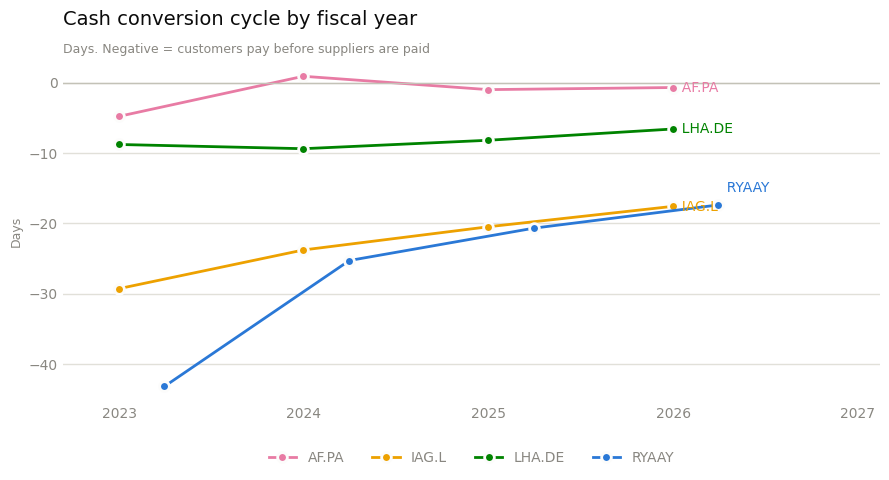

In [6]:
import matplotlib.dates as mdates

# categorical slots 1-4, assigned in fixed order and pinned per ticker so a
# change to TICKERS never repaints the survivors
SERIES_COLORS = {
    "RYAAY": "#2a78d6",   # blue
    "LHA.DE": "#008300",  # green
    "AF.PA": "#e87ba4",   # magenta
    "IAG.L": "#eda100",   # yellow
}
MUTED, BASELINE, INK, GRID, SURFACE = "#898781", "#c3c2b7", "#0b0b0b", "#e1e0d9", "#fcfcfb"


def plot_series(ax, metric):
    """One line per ticker for `metric`. Returns [ticker, x, y, colour] endpoints."""
    endpoints = []
    for ticker, grp in history.groupby(level="ticker"):
        s = grp[metric].droplevel("ticker").dropna()
        if s.empty:
            continue
        color = SERIES_COLORS.get(ticker, MUTED)
        ax.plot(s.index, s.values, color=color, linewidth=2, marker="o",
                markersize=7, markeredgecolor=SURFACE, markeredgewidth=2, label=ticker)
        endpoints.append([ticker, s.index[-1], s.values[-1], color])
    return endpoints


def direct_label_ends(ax, endpoints, gap_frac=0.055):
    """Label each line at its last point, so identity is never carried by colour
    alone. Carriers can finish within a hair of each other, so nudge the labels
    apart vertically where they would otherwise overprint."""
    lo, hi = ax.get_ylim()
    min_gap = gap_frac * (hi - lo)
    endpoints = sorted(endpoints, key=lambda e: e[2])
    for i in range(1, len(endpoints)):
        if endpoints[i][2] - endpoints[i - 1][2] < min_gap:
            endpoints[i][2] = endpoints[i - 1][2] + min_gap

    for ticker, x, label_y, color in endpoints:
        ax.annotate(f"  {ticker}", (x, label_y), color=color, fontsize=10,
                    va="center", ha="left", annotation_clip=False)


def style_axes(ax, ylabel=None):
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(colors=MUTED, labelsize=10, length=0)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)


def add_right_headroom(ax, frac=0.20):
    """Room on the right so the direct labels sit inside the figure."""
    x_lo, x_hi = ax.get_xlim()
    ax.set_xlim(x_lo - 0.04 * (x_hi - x_lo), x_hi + frac * (x_hi - x_lo))


def muted_legend(ax, **kwargs):
    legend = ax.legend(frameon=False, fontsize=10, **kwargs)
    for text in legend.get_texts():
        text.set_color(MUTED)
    return legend


fig, ax = plt.subplots(figsize=(9, 5))

direct_label_ends(ax, plot_series(ax, "CCC"))

ax.axhline(0, color=BASELINE, linewidth=1)
ax.set_title("Cash conversion cycle by fiscal year", fontsize=14, loc="left", color=INK, pad=26)
ax.text(0, 1.015, "Days. Negative = customers pay before suppliers are paid",
        transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom")
style_axes(ax, ylabel="Days")
add_right_headroom(ax)
muted_legend(ax, ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.22))

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "ccc_history.png"), dpi=200, bbox_inches="tight")
plt.show()

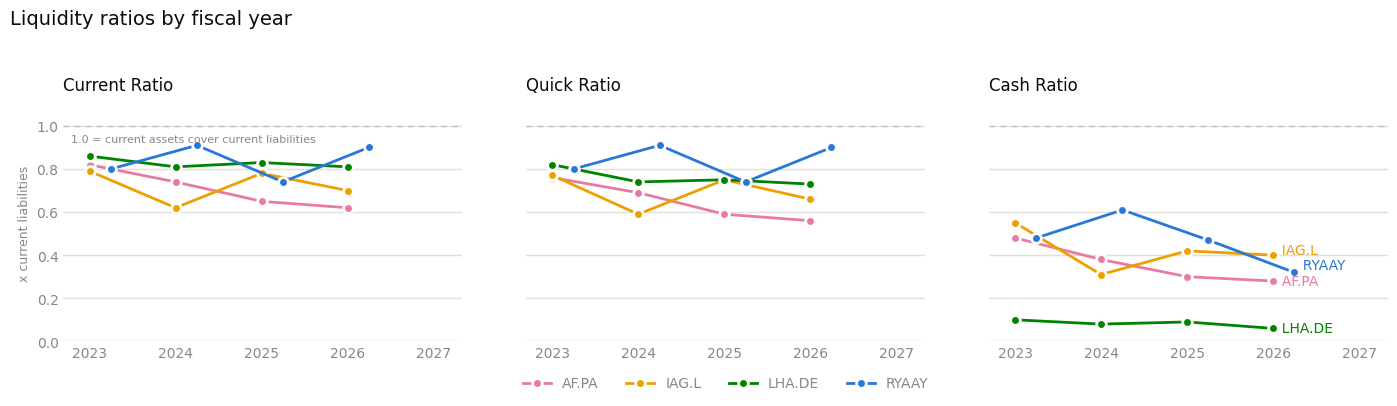

In [7]:
LIQUIDITY = ["Current Ratio", "Quick Ratio", "Cash Ratio"]

# One panel per ratio rather than 12 lines on one plot. All three are multiples
# of the same denominator (current liabilities), so both axes are shared - the
# panels stay directly comparable and the drop from Current to Cash is the point.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True, sharex=True)

for i, (ax, metric) in enumerate(zip(axes, LIQUIDITY)):
    endpoints = plot_series(ax, metric)

    # 1.0 = current assets exactly cover current liabilities
    ax.axhline(1.0, color=BASELINE, linewidth=1, linestyle=(0, (4, 4)))
    ax.set_title(metric, fontsize=12, loc="left", color=INK, pad=10)
    style_axes(ax, ylabel="x current liabilities" if i == 0 else None)

    # label only the last panel - repeating four labels per panel is noise,
    # and the shared legend already carries identity
    if i == len(LIQUIDITY) - 1:
        direct_label_ends(ax, endpoints, gap_frac=0.07)

axes[0].set_ylim(0, 1.1)
# shared x, so this widens every panel at once and keeps the three comparable
add_right_headroom(axes[0], frac=0.26)
axes[0].annotate(
    "1.0 = current assets cover current liabilities",
    xy=(0.02, 1.0), xycoords=("axes fraction", "data"),
    xytext=(0, -6), textcoords="offset points",
    fontsize=8, color=MUTED, va="top",
)

fig.suptitle("Liquidity ratios by fiscal year", fontsize=14, x=0.005, ha="left", color=INK)
muted_legend(axes[1], ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.26))

fig.tight_layout(rect=(0, 0.04, 1, 0.94))
fig.savefig(os.path.join(OUTPUT_DIR, "liquidity_history.png"), dpi=200, bbox_inches="tight")
plt.show()